In [1]:
import numpy as np
import pandas as pd
import time
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    precision_score, recall_score, f1_score, accuracy_score, 
    roc_auc_score, confusion_matrix
)
from sklearn.ensemble import StackingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.naive_bayes import GaussianNB
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SVMSMOTE, SMOTE, SMOTENC,ADASYN
import numpy as np
import pandas as pd
import time
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    precision_score, recall_score, f1_score, accuracy_score, 
    roc_auc_score, confusion_matrix
)
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.naive_bayes import GaussianNB
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SVMSMOTE

# Data

In [2]:
df_train = pd.read_csv(r"C:\mydata\G8Vitamin\data\final\24082025\processed_train.csv")

df_test = pd.read_csv(r"C:\mydata\G8Vitamin\data\final\24082025\processed_test.csv")

In [33]:
def vitamin_d_classification_nmol(value_nmol_l: float) -> int:
    """
    Classify Vitamin D level into 4 categories (numeric) based on nmol/L:
    0 = Severe Deficiency (<25 nmol/L)
    1 = Deficiency (25–49 nmol/L)
    2 = Insufficiency (50–74 nmol/L)
    3 = Sufficiency (>=75 nmol/L)
    
    Parameters:
        value_nmol_l (float): Serum 25(OH)D concentration in nmol/L.
        
    Returns:
        int: Vitamin D category label (0–3).
    """
    if value_nmol_l < 25:
        return 0
    elif 25 <= value_nmol_l < 50:
        return 1
    else:
        return 2





In [34]:
df_train['label'] = df_train['VitaminD'].apply(vitamin_d_classification_nmol)
df_test['label'] = df_test['VitaminD'].apply(vitamin_d_classification_nmol)

In [3]:
columns_remove = [
    'VitaminD',
    'YearStart',
]

In [36]:
df_train['ALT_bin'] = pd.cut(df_train['ALT'], bins=[0, 40, 80, np.inf], labels=[0,1,2])
df_train['AST_bin'] = pd.cut(df_train['AST'], bins=[0, 40, 80, np.inf], labels=[0,1,2])


In [37]:
df_test['ALT_bin'] = pd.cut(df_test['ALT'], bins=[0, 40, 80, np.inf], labels=[0,1,2])
df_test['AST_bin'] = pd.cut(df_test['AST'], bins=[0, 40, 80, np.inf], labels=[0,1,2])


In [38]:
df_train['AST_ALT_ratio'] = df_train['AST'] / (df_train['ALT'] + 1e-6)
df_test['AST_ALT_ratio'] = df_test['AST'] / (df_test['ALT'] + 1e-6)

In [4]:
df_train = df_train[df_train['milk_consumption']<=3]
df_test = df_test[df_test['milk_consumption']<=3]

In [5]:
df_train.drop(columns=columns_remove, inplace=True)
df_test.drop(columns=columns_remove, inplace=True)

In [6]:
category_columns = [
    'Gender','Race' ,'SmokeFam','label','milk_consumption'
]

In [7]:
unuseful_features = ['SmokeFam','WaistCircumference','AST','UricAcid','LDLCholesterol','Hematocrit','MeanCellHemoglobin','PlateletCount', 'MeanPlateletVolume','familysize']

In [8]:
df_train.drop(columns=unuseful_features,inplace=True)
df_test = df_test[df_train.columns]

In [9]:
df_train.columns

Index(['Gender', 'Age', 'Race', 'PIR', 'BMI', 'FastingGlucose', 'ALT',
       'AlkalinePhosphotase', 'Triglycerides', 'Creatinine', 'HDLCholesterol',
       'Hemoglobin', 'MeanCellVolumn', 'RedCellDistributionWidth', 'Hba1c',
       'milk_consumption', 'label'],
      dtype='object')

# Training and evaluation

## stacking setup

In [20]:
#model definition
dt_setups = {
    "Shallow": DecisionTreeClassifier(criterion="gini", max_depth=5, min_samples_split=10, min_samples_leaf=4, random_state=42),
    "Balanced": DecisionTreeClassifier(criterion="entropy", max_depth=10, min_samples_split=5, min_samples_leaf=2, random_state=42),
    "Deep": DecisionTreeClassifier(criterion="gini", max_depth=20, min_samples_split=2, min_samples_leaf=1, random_state=42),
    "Randomized": DecisionTreeClassifier(criterion="log_loss", splitter="random", max_depth=None, min_samples_split=20, min_samples_leaf=6, random_state=42),
    "WideFeatures": DecisionTreeClassifier(criterion="entropy", splitter="best", max_depth=30, min_samples_split=5, min_samples_leaf=2, max_features="sqrt", random_state=42)
}
gbc_setups = {
    "Balanced": GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42),
    "ShallowFast": GradientBoostingClassifier(n_estimators=80, learning_rate=0.2, max_depth=2, subsample=0.8, random_state=42),
    "Regularized": GradientBoostingClassifier(n_estimators=200, learning_rate=0.01, max_depth=4, min_samples_split=20, min_samples_leaf=5, random_state=42),
    "Deep": GradientBoostingClassifier(n_estimators=300, learning_rate=0.05, max_depth=6, subsample=0.9, random_state=42),
    "RobustSubsample": GradientBoostingClassifier(n_estimators=150, learning_rate=0.08, max_depth=5, subsample=0.7, max_features="sqrt", random_state=42),
    "Conservative": GradientBoostingClassifier(n_estimators=500, learning_rate=0.01, max_depth=3, subsample=0.8, max_features="log2", random_state=42)
}

rf_setups = {
    "Balanced": RandomForestClassifier(
        n_estimators=100, max_depth=None, random_state=42
    ),
    "ShallowFast": RandomForestClassifier(
        n_estimators=50, max_depth=5, max_features="sqrt", random_state=42
    ),
    "Deep": RandomForestClassifier(
        n_estimators=300, max_depth=20, min_samples_split=5,
        min_samples_leaf=2, random_state=42
    ),
    "Regularized": RandomForestClassifier(
        n_estimators=100, max_depth=10, min_samples_split=10,
        min_samples_leaf=4, max_features=0.6, random_state=42
    ),
    "Conservative": RandomForestClassifier(
        n_estimators=500, max_depth=None, min_samples_split=20,
        min_samples_leaf=10, max_features="log2", random_state=42
    ),
    "RobustSubsample": RandomForestClassifier(#no ok
        n_estimators=150, max_depth=15, min_samples_split=5,
        min_samples_leaf=3, bootstrap=True, max_features="sqrt",
        random_state=42
    ),
    "Lightweight": RandomForestClassifier(
        n_estimators=50, max_depth=8, max_features=0.5, random_state=42
    ),
    "Heavy": RandomForestClassifier(
        n_estimators=1000, max_depth=None, min_samples_split=2,
        min_samples_leaf=1, max_features=None, random_state=42, n_jobs=-1
    ),
}

#Best: GradientBoostingClassifier(n_estimators=80, learning_rate=0.05, random_state=42)
base_learners = [
    ('lightgbm', LGBMClassifier(n_estimators=120, max_depth=6, num_leaves=31, learning_rate=0.05, random_state=42)),
    ('xgboost', XGBClassifier(n_estimators=80, learning_rate=0.066, random_state=42, verbosity=0)),
    #('gb', GradientBoostingClassifier(n_estimators=80, learning_rate=0.05, random_state=42)),
    ('RandomForest', rf_setups['Regularized']),
    # ('dt', dt_setups['Shallow']),  
    # ('LogisticRegression', LogisticRegression(max_iter=1000, random_state=42)),
    # ('SVM', SVC(kernel='rbf', C=10, gamma=0.01, class_weight='balanced', probability=True, random_state=42)),
    ('nb', GaussianNB(var_smoothing= 1e-10)),
]


# ====== 3) Meta-learner ======
# meta_learner = LogisticRegression(max_iter=1000, random_state=42)
meta_learner = LogisticRegression(
    max_iter=3000,
    solver='saga',          # saga supports L1, L2, elasticnet
    penalty='elasticnet',   # mix between L1 and L2
    l1_ratio=0.6,           # 0.0 -> pure L2, 1.0 -> pure L1
    C=1.0,                  # regularization strength
    class_weight='balanced',
    random_state=42
)
# ====== 4) Stacking classifier ======
stacking_clf = StackingClassifier(
    estimators=base_learners,
    final_estimator=meta_learner,
    stack_method="predict_proba",  # use probabilities from base models
    n_jobs=-1
)

In [14]:
df_train.columns

Index(['Gender', 'Age', 'Race', 'PIR', 'BMI', 'FastingGlucose', 'ALT',
       'AlkalinePhosphotase', 'Triglycerides', 'Creatinine', 'HDLCholesterol',
       'Hemoglobin', 'MeanCellVolumn', 'RedCellDistributionWidth', 'Hba1c',
       'milk_consumption', 'label'],
      dtype='object')

## All classifier setup

In [38]:

classifiers = {
    'LightGBM': LGBMClassifier(n_estimators=120, max_depth=5, num_leaves=31, learning_rate=0.05, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=80, learning_rate=0.066, random_state=42, verbosity=0),
    'GradiantBoosting': GradientBoostingClassifier(n_estimators=80, learning_rate=0.05, random_state=42),
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Naive Bayes': GaussianNB(var_smoothing=1e-10),
    # #'SVM': SVC(kernel='rbf', C=10, gamma=0.01, class_weight='balanced', probability=True, random_state=42),
    'Stacking':stacking_clf
}

## Training and evaluation

In [39]:
# ====== 0) Train/test split ======
X_train_raw = df_train.drop(columns='label')
y_train = df_train['label']
X_test_raw = df_test.drop(columns=['label'])
y_test = df_test['label']

categorical_cols = ['Gender','Race','milk_consumption']
numeric_cols = [col for col in df_train.columns if col not in categorical_cols and col !='label']

# ====== 1) Preprocessor ======
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_cols),
        # ('num', StandardScaler(), numeric_cols),
    ],
    remainder='passthrough'
)

# ====== 3) SVMSMOTE setup ======
svmsmote = SVMSMOTE(
    random_state=42,
    sampling_strategy='not majority',
    k_neighbors=20,
    m_neighbors=40,
    svm_estimator=SVC(kernel="rbf", gamma="scale", C=1.0)
)
#svmsmote = ADASYN(random_state=42, sampling_strategy="auto", n_neighbors=20)
#SMOTE(random_state=42, sampling_strategy="auto", k_neighbors=20)
# ====== 4) Wrapper for imblearn pipelines ======
class ImblearnWrapper(BaseEstimator, ClassifierMixin):
    def __init__(self, pipeline):
        self.pipeline = pipeline
    def fit(self, X, y):
        self.pipeline.fit(X, y)
        return self
    def predict(self, X):
        return self.pipeline.predict(X)
    def predict_proba(self, X):
        return self.pipeline.predict_proba(X)


# ====== 5) Train & evaluate ======
rows = []

for name, clf in classifiers.items():
    print(f"\n🚀 Training {name} with SVMSMOTE...")
    pipeline = ImbPipeline(steps=[
        ('preprocessor', preprocessor),
        ('smote', svmsmote),
        ('classifier', clf)
    ])
    wrapped_model = ImblearnWrapper(pipeline)

    try:
        start = time.time()
        wrapped_model.fit(X_train_raw, y_train)
        train_time = time.time() - start

        y_pred = wrapped_model.predict(X_test_raw)
        y_proba = wrapped_model.predict_proba(X_test_raw)

        # ===== Global metrics =====
        acc = accuracy_score(y_test, y_pred)
        f1_macro = f1_score(y_test, y_pred, average='macro', zero_division=0)
        f1_weighted = f1_score(y_test, y_pred, average='weighted', zero_division=0)

        # AUC
        if len(np.unique(y_test)) == 2:
            auc = roc_auc_score(y_test, y_proba[:, 1])
        else:
            auc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro')

        # ===== Per-class metrics (generalized) =====
        labels = np.unique(y_test)   # e.g., [0,1,2,3]
        cm = confusion_matrix(y_test, y_pred, labels=labels)
        f1_per_class = f1_score(y_test, y_pred, average=None, labels=labels, zero_division=0)

        for i, cls in enumerate(labels):
            TP = cm[i, i]
            FN = cm[i, :].sum() - TP
            FP = cm[:, i].sum() - TP
            TN = cm.sum() - (TP + FN + FP)

            PPV = TP / (TP + FP) if (TP + FP) > 0 else 0  # Precision
            NPV = TN / (TN + FN) if (TN + FN) > 0 else 0
            SEN = TP / (TP + FN) if (TP + FN) > 0 else 0  # Recall
            SPE = TN / (TN + FP) if (TN + FP) > 0 else 0
            F1  = f1_per_class[i]

            # Add row with per-class metrics
            rows.append({
                "Model": name,
                "Label": cls,
                "Training time": round(train_time, 4) if cls == labels[0] else None,
                "ACC": round(acc, 4) if cls == labels[0] else None,
                "F1_macro": round(f1_macro, 4) if cls == labels[0] else None,
                "F1_weighted": round(f1_weighted, 4) if cls == labels[0] else None,
                "AUC": round(auc, 4) if cls == labels[0] else None,
                "PPV": round(PPV, 4),
                "NPV": round(NPV, 4),
                "SEN": round(SEN, 4),
                "SPE": round(SPE, 4),
                "F1_class": round(F1, 4),
            })

        print(f"✅ {name} - ACC={acc:.4f}, F1_macro={f1_macro:.4f}, AUC={auc:.4f}")

    except Exception as e:
        print(f"❌ Error training {name}: {e}")


# ====== 6) Save results ======
results_df = pd.DataFrame(rows)

print("\n📊 FINAL TABLE (Excel format-ready):")
print(results_df)

output_file = "vitamin_d_results4.csv"
results_df.to_csv(output_file, index=False)
print(f"\n✅ Exported results to {output_file}")



🚀 Training LightGBM with SVMSMOTE...
[LightGBM] [Info] Number of positive: 12380, number of negative: 12380
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001825 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5349
[LightGBM] [Info] Number of data points in the train set: 24760, number of used features: 21
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -in

c:\mydata\G8Vitamin\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\mydata\G8Vitamin\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


✅ XGBoost - ACC=0.7248, F1_macro=0.6633, AUC=0.7389

🚀 Training GradiantBoosting with SVMSMOTE...
✅ GradiantBoosting - ACC=0.7127, F1_macro=0.6566, AUC=0.7294

🚀 Training RandomForest with SVMSMOTE...
✅ RandomForest - ACC=0.7205, F1_macro=0.6371, AUC=0.7262

🚀 Training Naive Bayes with SVMSMOTE...
✅ Naive Bayes - ACC=0.6419, F1_macro=0.6190, AUC=0.6652

🚀 Training Stacking with SVMSMOTE...
✅ Stacking - ACC=0.7140, F1_macro=0.6369, AUC=0.7235

📊 FINAL TABLE (Excel format-ready):
               Model  Label  Training time     ACC  F1_macro  F1_weighted  \
0           LightGBM    0.0         4.7318  0.7317    0.6649       0.7217   
1           LightGBM    1.0            NaN     NaN       NaN          NaN   
2            XGBoost    0.0         5.0592  0.7248    0.6633       0.7179   
3            XGBoost    1.0            NaN     NaN       NaN          NaN   
4   GradiantBoosting    0.0        25.5317  0.7127    0.6566       0.7093   
5   GradiantBoosting    1.0            NaN     NaN     

c:\mydata\G8Vitamin\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\mydata\G8Vitamin\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [ ]:
# --- IMPORTS ---
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report
from sklearn.pipeline import Pipeline
from sklearn.ensemble import AdaBoostClassifier, ExtraTreesClassifier, RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# ====== 1) Define feature types ======
categorical_cols = ['Gender','Race','milk_consumption']
numeric_cols = [col for col in df_train.columns if col not in categorical_cols and col !='label']

# ====== 2) Preprocessor ======
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

# ====== 3) SMOTE ======
smote = SVMSMOTE(
    sampling_strategy='minority',
    k_neighbors=20,
    m_neighbors=40,
    random_state=42
)

classifiers = {
    'LightGBM': LGBMClassifier(n_estimators=80, max_depth=6, num_leaves=31, learning_rate=0.05, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=80, learning_rate=0.05, random_state=42, verbosity=0),
    'GradiantBoosting': GradientBoostingClassifier(n_estimators=80, learning_rate=0.05, random_state=42),
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Naive Bayes': GaussianNB(var_smoothing=1e-10),
    # #'SVM': SVC(kernel='rbf', C=10, gamma=0.01, class_weight='balanced', probability=True, random_state=42),
    'Stacking':stacking_clf
}
# ====== 4) Base models ======
clf1 = LGBMClassifier(n_estimators=100, max_depth=5, num_leaves=16, learning_rate=0.05, random_state=42)
clf2 = XGBClassifier(n_estimators=80, learning_rate=0.05, random_state=42, verbosity=0)
clf3 = RandomForestClassifier(n_estimators=100, random_state=42)
clf4 = GaussianNB()
clf5 = LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced")
clf6 = GradientBoostingClassifier(n_estimators=120, learning_rate=0.05, random_state=42)
clf7 = AdaBoostClassifier(n_estimators=100, random_state=42)
clf8 = ExtraTreesClassifier(n_estimators=150, random_state=42)
clf9 = SVC(kernel='rbf', C=10, gamma=0.01, probability=True, random_state=42, class_weight="balanced")

# ====== 5) Voting Classifier ======
voting_clf = VotingClassifier(
    estimators=[
        ('lgbm', clf1),
        ('xgb', clf2),
        ('rf', clf3),
        ('nb', clf4),
        ('lr', clf5),
        ('gb', clf6),
        ('ada', clf7),
        ('et', clf8),
        ('svc', clf9)
    ],
    voting='soft'   # ✅ use soft for imbalanced data
)

# ====== 6) Full pipeline ======
pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', smote),
    ('voting', voting_clf)
])

# ====== 7) Train & Evaluate ======
pipeline.fit(X_train_raw, y_train)
y_pred = pipeline.predict(X_test_raw)

print(classification_report(y_test, y_pred))


[LightGBM] [Info] Number of positive: 12380, number of negative: 12380
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002165 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5868
[LightGBM] [Info] Number of data points in the train set: 24760, number of used features: 24
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
              precision    recall  f1-score   support

         0.0       0.80      0.76      0.78      3193
         1.0       0.52      0.58      0.55      1437

    accuracy                           0.70      4630
   macro avg       0.66      0.67      0.67      4630
weighted avg       0.71      0.70      0.71      4630



c:\mydata\G8Vitamin\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [48]:
# --- IMPORTS ---
import numpy as np
import pandas as pd
import time
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    precision_score, recall_score, f1_score, accuracy_score, 
    roc_auc_score, confusion_matrix
)
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.inspection import permutation_importance

from imblearn.over_sampling import SVMSMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

# ====== 0) Train/test split ======
X_train_raw = df_train.drop(columns='label')
y_train = df_train['label']
X_test_raw = df_test.drop(columns=['label'])
y_test = df_test['label']

categorical_cols = ['Gender','Race','milk_consumption']
numeric_cols = [col for col in df_train.columns if col not in categorical_cols and col !='label']

# ====== 1) Preprocessor ======
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_cols),
        ('num', StandardScaler(), numeric_cols),
    ],
    remainder='passthrough'
)

# ====== 2) Classifiers ======
classifiers = {
    "RandomForest": RandomForestClassifier(random_state=42),
    "GradientBoosting": GradientBoostingClassifier(random_state=42),
    "LogisticRegression": LogisticRegression(max_iter=2000, solver="liblinear"),
    # "SVC_rbf": SVC(kernel="rbf", probability=True, random_state=42),
    # "KNN": KNeighborsClassifier(n_neighbors=5),
    # "NaiveBayes": GaussianNB()
}

# ====== 3) SVMSMOTE setup ======
svmsmote = SVMSMOTE(
    random_state=42,
    sampling_strategy='not majority',
    k_neighbors=20,
    m_neighbors=40,
    svm_estimator=SVC(kernel="rbf", gamma="scale", C=1.0)
)

# ====== 4) Wrapper for imblearn pipelines ======
class ImblearnWrapper(BaseEstimator, ClassifierMixin):
    def __init__(self, pipeline):
        self.pipeline = pipeline
    def fit(self, X, y):
        self.pipeline.fit(X, y)
        return self
    def predict(self, X):
        return self.pipeline.predict(X)
    def predict_proba(self, X):
        return self.pipeline.predict_proba(X)

# ====== 5) Train & evaluate ======
rows = []
feature_importance_rows = []

for name, clf in classifiers.items():
    print(f"\n🚀 Training {name} with SVMSMOTE...")
    pipeline = ImbPipeline(steps=[
        ('preprocessor', preprocessor),
        ('smote', svmsmote),
        ('classifier', clf)
    ])
    wrapped_model = ImblearnWrapper(pipeline)

    try:
        start = time.time()
        wrapped_model.fit(X_train_raw, y_train)
        train_time = time.time() - start

        y_pred = wrapped_model.predict(X_test_raw)
        y_proba = wrapped_model.predict_proba(X_test_raw)

        # ===== Global metrics =====
        acc = accuracy_score(y_test, y_pred)
        f1_macro = f1_score(y_test, y_pred, average='macro', zero_division=0)
        f1_weighted = f1_score(y_test, y_pred, average='weighted', zero_division=0)

        # AUC
        if len(np.unique(y_test)) == 2:
            auc = roc_auc_score(y_test, y_proba[:, 1])
        else:
            auc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro')

        # ===== Per-class metrics =====
        labels = np.unique(y_test)
        cm = confusion_matrix(y_test, y_pred, labels=labels)
        f1_per_class = f1_score(y_test, y_pred, average=None, labels=labels, zero_division=0)

        for i, cls in enumerate(labels):
            TP = cm[i, i]
            FN = cm[i, :].sum() - TP
            FP = cm[:, i].sum() - TP
            TN = cm.sum() - (TP + FN + FP)

            PPV = TP / (TP + FP) if (TP + FP) > 0 else 0
            NPV = TN / (TN + FN) if (TN + FN) > 0 else 0
            SEN = TP / (TP + FN) if (TP + FN) > 0 else 0
            SPE = TN / (TN + FP) if (TN + FP) > 0 else 0
            F1  = f1_per_class[i]

            rows.append({
                "Model": name,
                "Label": cls,
                "Training time": round(train_time, 4) if cls == labels[0] else None,
                "ACC": round(acc, 4) if cls == labels[0] else None,
                "F1_macro": round(f1_macro, 4) if cls == labels[0] else None,
                "F1_weighted": round(f1_weighted, 4) if cls == labels[0] else None,
                "AUC": round(auc, 4) if cls == labels[0] else None,
                "PPV": round(PPV, 4),
                "NPV": round(NPV, 4),
                "SEN": round(SEN, 4),
                "SPE": round(SPE, 4),
                "F1_class": round(F1, 4),
            })

        print(f"✅ {name} - ACC={acc:.4f}, F1_macro={f1_macro:.4f}, AUC={auc:.4f}")

        # ===== Feature importance extraction =====
        # Get SMOTE-resampled training data (processed)
        X_train_processed = preprocessor.fit_transform(X_train_raw)
        X_res, y_res = svmsmote.fit_resample(X_train_processed, y_train)

        # Refit classifier directly on resampled data
        clf.fit(X_res, y_res)

        # Get feature names
        cat_features = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols)
        feature_names = np.concatenate([cat_features, numeric_cols])

        # Tree/linear models
        if hasattr(clf, "feature_importances_"):
            importances = clf.feature_importances_
        elif hasattr(clf, "coef_"):
            importances = np.mean(np.abs(clf.coef_), axis=0)
        else:
            # Fallback: permutation importance
            perm = permutation_importance(clf, X_res, y_res, n_repeats=5, random_state=42, n_jobs=-1)
            importances = perm.importances_mean

        for feat, imp in zip(feature_names, importances):
            feature_importance_rows.append({
                "Model": name,
                "Feature": feat,
                "Importance": imp
            })

    except Exception as e:
        print(f"❌ Error training {name}: {e}")

# ====== 6) Save results ======
results_df = pd.DataFrame(rows)
feature_importance_df = pd.DataFrame(feature_importance_rows)

print("\n📊 FINAL METRICS TABLE:")
print(results_df)

print("\n📊 FEATURE IMPORTANCE TABLE (top 15 across all models):")
print(feature_importance_df.sort_values("Importance", ascending=False).head(15))

results_df.to_csv("vitamin_d_results2.csv", index=False)
feature_importance_df.to_csv("feature_importance_results.csv", index=False)

print("\n✅ Exported results to vitamin_d_results2.csv and feature_importance_results.csv")



🚀 Training RandomForest with SVMSMOTE...
✅ RandomForest - ACC=0.6732, F1_macro=0.4621, AUC=0.7346

🚀 Training GradientBoosting with SVMSMOTE...
✅ GradientBoosting - ACC=0.6637, F1_macro=0.4883, AUC=0.7413

🚀 Training LogisticRegression with SVMSMOTE...


c:\mydata\G8Vitamin\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(


✅ LogisticRegression - ACC=0.5866, F1_macro=0.4529, AUC=0.7287


c:\mydata\G8Vitamin\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(



📊 FINAL METRICS TABLE:
                Model  Label  Training time     ACC  F1_macro  F1_weighted  \
0        RandomForest      0        34.5668  0.6732    0.4621       0.6726   
1        RandomForest      1            NaN     NaN       NaN          NaN   
2        RandomForest      2            NaN     NaN       NaN          NaN   
3    GradientBoosting      0        73.3933  0.6637    0.4883       0.6728   
4    GradientBoosting      1            NaN     NaN       NaN          NaN   
5    GradientBoosting      2            NaN     NaN       NaN          NaN   
6  LogisticRegression      0        34.9979  0.5866    0.4529       0.6188   
7  LogisticRegression      1            NaN     NaN       NaN          NaN   
8  LogisticRegression      2            NaN     NaN       NaN          NaN   

      AUC     PPV     NPV     SEN     SPE  F1_class  
0  0.7346  0.1840  0.9607  0.1150  0.9770    0.1415  
1     NaN  0.4327  0.8021  0.4778  0.7716    0.4541  
2     NaN  0.7974  0.5372  0.7839

In [49]:
df = pd.read_csv(r"C:\mydata\G8Vitamin\data\final\24082025\processed_train.csv")

C:\Users\iseT1enLoc\AppData\Local\Temp\ipykernel_14932\2179144783.py:33: DeprecationWarning: Non-integer input passed to bincount. In a future version of NumPy, this will be an error. (Deprecated NumPy 2.1)
  print("Before SMOTE:", X_train.shape, np.bincount(y_train))
C:\Users\iseT1enLoc\AppData\Local\Temp\ipykernel_14932\2179144783.py:34: DeprecationWarning: Non-integer input passed to bincount. In a future version of NumPy, this will be an error. (Deprecated NumPy 2.1)
  print("After SMOTE :", X_resampled.shape, np.bincount(y_resampled))


Before SMOTE: (13023, 26) [9945 3078]
After SMOTE : (19890, 26) [9945 9945]


c:\mydata\G8Vitamin\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [14:32:29] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


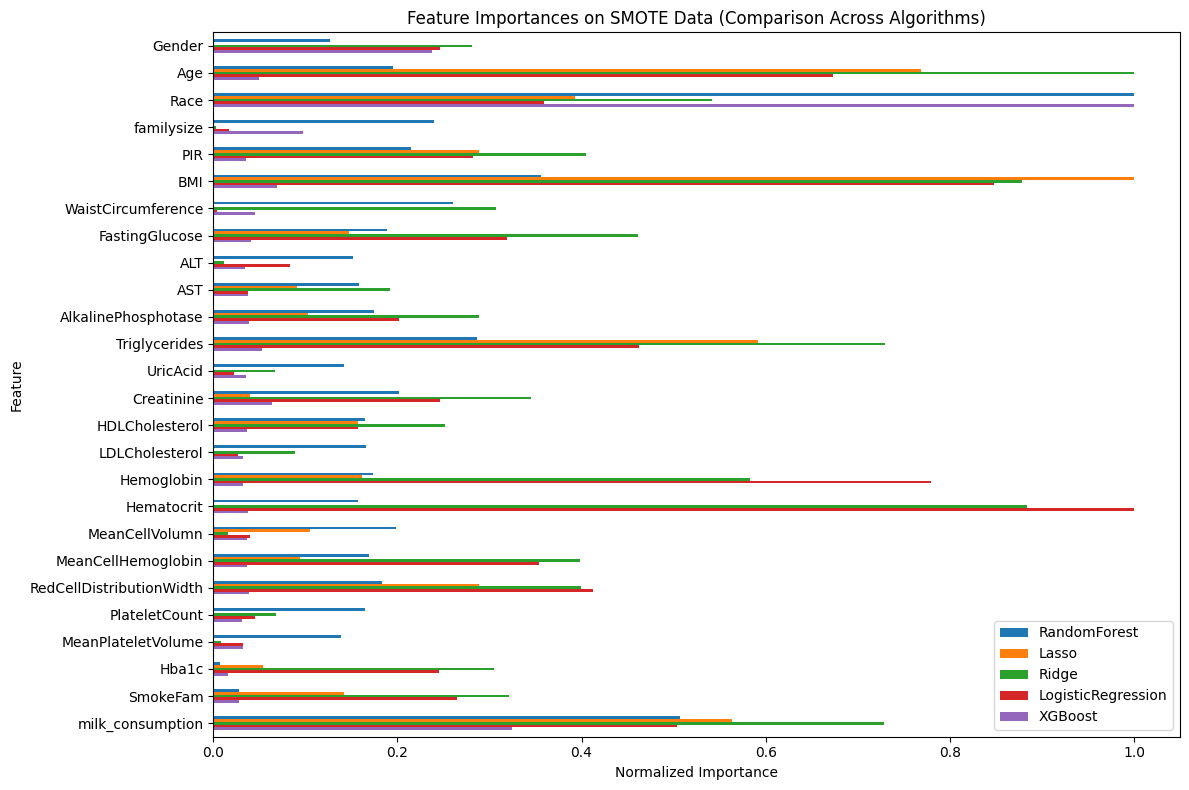


📊 Top 30 features by RandomForest importance (SMOTE data):
                     Feature  RandomForest     Lasso     Ridge  \
2                       Race      1.000000  0.393165  0.541346   
25          milk_consumption      0.506801  0.563272  0.728443   
5                        BMI      0.356268  1.000000  0.878236   
11             Triglycerides      0.286077  0.591888  0.730004   
6         WaistCircumference      0.260632  0.000000  0.307600   
3                 familysize      0.239693  0.000000  0.003418   
4                        PIR      0.214479  0.288503  0.405326   
13                Creatinine      0.201627  0.039675  0.345026   
18            MeanCellVolumn      0.198268  0.105170  0.015766   
1                        Age      0.195532  0.768596  1.000000   
7             FastingGlucose      0.188298  0.147360  0.461739   
20  RedCellDistributionWidth      0.182931  0.288550  0.399823   
10       AlkalinePhosphotase      0.174925  0.102514  0.288175   
16              

In [54]:
# --- IMPORTS ---
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import Lasso, Ridge, LogisticRegression
import xgboost as xgb
import matplotlib.pyplot as plt

from imblearn.over_sampling import SMOTE  # you can also swap for SVMSMOTE

# --- 0) Load dataset ---
# Assume df is already loaded
X = df.drop(columns=['label', 'YearStart', 'VitaminD'])  # drop target + metadata
y = df['label']

# --- 1) Train-test split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# --- 2) Scaling for linear models ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- 3) Apply SMOTE on training data ---
smote = SVMSMOTE(random_state=42,k_neighbors=20,m_neighbors=40, sampling_strategy="not majority")
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)
X_resampled_scaled = scaler.fit_transform(X_resampled)  # scale AFTER SMOTE for linear models

print("Before SMOTE:", X_train.shape, np.bincount(y_train))
print("After SMOTE :", X_resampled.shape, np.bincount(y_resampled))

# --- 4) Models and Feature Importances ---

# 4.1 Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_resampled, y_resampled)
rf_importance = rf.feature_importances_

# 4.2 Lasso
lasso = Lasso(alpha=0.01, random_state=42, max_iter=5000)
lasso.fit(X_resampled_scaled, y_resampled)
lasso_importance = np.abs(lasso.coef_)

# 4.3 Ridge
ridge = Ridge(alpha=1.0, random_state=42, max_iter=5000)
ridge.fit(X_resampled_scaled, y_resampled)
ridge_importance = np.abs(ridge.coef_)

# 4.4 Logistic Regression
logreg = LogisticRegression(max_iter=2000, solver="liblinear", random_state=42)
logreg.fit(X_resampled_scaled, y_resampled)
logreg_importance = np.abs(logreg.coef_[0])

# 4.5 XGBoost
xgb_model = xgb.XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    n_estimators=200,
    random_state=42
)
xgb_model.fit(X_resampled, y_resampled)
xgb_importance = xgb_model.feature_importances_

# --- 5) Aggregate into DataFrame ---
feature_names = X.columns
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'RandomForest': rf_importance,
    'Lasso': lasso_importance,
    'Ridge': ridge_importance,
    'LogisticRegression': logreg_importance,
    'XGBoost': xgb_importance
})

# Normalize each column for visualization
for col in ['RandomForest', 'Lasso', 'Ridge', 'LogisticRegression', 'XGBoost']:
    max_val = importance_df[col].max()
    if max_val > 0:
        importance_df[col] = importance_df[col] / max_val

# --- 6) Plot top 30 features ---
top_features = importance_df.sort_values(by='RandomForest', ascending=False).head(30)['Feature']
importance_df_top = importance_df[importance_df['Feature'].isin(top_features)]

importance_df_top.set_index('Feature').plot(kind='barh', figsize=(12, 8))
plt.title("Feature Importances on SMOTE Data (Comparison Across Algorithms)")
plt.xlabel("Normalized Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# --- 7) Print results ---
print("\n📊 Top 30 features by RandomForest importance (SMOTE data):")
print(importance_df.sort_values(by='RandomForest', ascending=False).head(30))

# --- 8) Export results ---
importance_df.to_csv("feature_importance_smote.csv", index=False)
print("\n✅ Exported feature importance (SMOTE data) to feature_importance_smote.csv")
